# **Hotel Revenue Analytics — Exploratory Data Analysis in Python**

**Dataset:** Hotel Booking Demand (Antonio et al., 2019)  
**Source File:** `hotel_bookings.xlsx`  
**Worksheet Used:** `CLEAN`  
**Analyst:** Madhusudan Rajpurohit  
**Date:** 1 June 2026  

---

## **Overview**

This notebook continues the project after Excel-based data cleaning.  
The cleaned dataset is imported directly from the `CLEAN` worksheet for analysis.  
All monetary values are expressed in EUR (€), and the dataset reflects hotel booking activity in Portugal.  

## **Analysis Covered**

- Summary statistics
- Exploratory data analysis
- Revenue patterns
- Cancellation behavior

***
## **Column Definitions**

| Column Name | Purpose |
| --- | --- |
| `hotel` | Hotel type (Resort Hotel or City Hotel). |
| `is_cancelled` | Indicates whether the booking was cancelled (1 = Yes, 0 = No). |
| `lead_time` | Number of days between booking date and arrival date. |
| `arrival_date_year` | Arrival year of the booking. |
| `arrival_date_month` | Arrival month of the booking. |
| `arrival_date_week_number` | Week number of the arrival date. |
| `arrival_date_day_of_month` | Day of the month for arrival. |
| `stays_in_weekend_nights` | Number of weekend nights stayed. |
| `stays_in_week_nights` | Number of weekday nights stayed. |
| `adults` | Number of adults in the booking. |
| `children` | Number of children in the booking. |
| `babies` | Number of babies in the booking. |
| `meal` | Meal plan booked by the guest. |
| `country` | Country of origin of the guest. |
| `market_segment` | Market segment through which the booking was made. |
| `distribution_channel` | Booking distribution channel. |
| `is_repeated_guest` | Indicates whether the guest is a repeated guest. |
| `previous_cancellations` | Number of previous bookings cancelled by the customer. |
| `previous_bookings_not_canceled` | Number of previous bookings not cancelled by the customer. |
| `reserved_room_type` | Originally reserved room type. |
| `assigned_room_type` | Actually assigned room type at check-in. |
| `booking_changes` | Number of changes made to the booking. |
| `deposit_type` | Type of deposit made for the booking. |
| `agent` | Travel agent ID associated with the booking. |
| `company` | Company ID associated with the booking. |
| `is_corporate_booking` | Indicates whether the booking is corporate. |
| `customer_group` | Grouping of customers based on booking pattern or business rule. |
| `days_in_waiting_list` | Number of days the booking was in the waiting list. |
| `customer_type` | Type of customer (for example, transient or contract). |
| `adr` | Average Daily Rate, or average room price per night. |
| `required_car_parking_spaces` | Number of parking spaces requested. |
| `total_of_special_requests` | Total number of special requests made by the guest. |
| `reservation_status` | Final reservation status of the booking. |
| `reservation_status_date` | Date when the reservation status was last updated. |
| `total_nights` | Total nights stayed, including weekday and weekend nights. |
| `revenue` | Estimated booking revenue. |
| `arrival_date` | Full arrival date combined into one field. |
| `guest_count` | Total number of guests in the booking. |
| `room_changed` | Indicates whether assigned room differed from reserved room. |

***
# **Importing Libraries**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

***
# **1. Load Data and Initial Inspection**

In [2]:
# First check exact sheet names in your file
xl = pd.ExcelFile('hotel_bookings.xlsx')
print("Sheets found:", xl.sheet_names)

Sheets found: ['hotel_bookings_raw_data', 'CLEAN', 'PIVOT_TABLES AND CHARTS']


In [3]:
df = pd.read_excel("hotel_bookings.xlsx", sheet_name="CLEAN")

In [5]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'is_corporate_booking', 'customer_group',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_nights',
       'revenue', 'arrival_date', 'guest_count', 'room_changed'],
      dtype='object')

In [8]:
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 85,617 rows × 39 columns


In [7]:
print(f"Columns: {df.columns.tolist()}")

Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'is_corporate_booking', 'customer_group', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'total_nights', 'revenue', 'arrival_date', 'guest_count', 'room_changed']


In [ ]:
# First 5 rows of the dataset to check data types and cleaning results

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,revenue,arrival_date,guest_count,room_changed
0,Resort Hotel,False,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,75.0,2015-07-01,1,Changed
1,Resort Hotel,False,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,75.0,2015-07-01,1,No change
2,Resort Hotel,False,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,196.0,2015-07-01,2,No change
3,Resort Hotel,False,0,2015,July,27,1,0,2,2,...,107.0,0,0,Check-Out,2015-07-03,2,214.0,2015-07-01,2,No change
4,Resort Hotel,False,9,2015,July,27,1,0,2,2,...,103.0,0,1,Check-Out,2015-07-03,2,206.0,2015-07-01,2,No change


In [12]:
print(f"Shape              : {df.shape}")
print(f"Duplicate rows     : {df.duplicated().sum():,}")
print(f"ADR minimum        : {df['adr'].min():.2f}")
print(f"ADR maximum        : {df['adr'].max():.2f}")
print(f"Zero-night rows    : {((df['stays_in_week_nights']+df['stays_in_weekend_nights'])==0).sum():,}  ")
print(f"Missing children   : {df['children'].isna().sum():,}  ")
print(f"Missing country    : {df['country'].isna().sum():,}  ")

Shape              : (85617, 39)
Duplicate rows     : 0
ADR minimum        : 0.26
ADR maximum        : 5400.00
Zero-night rows    : 0  
Missing children   : 0  
Missing country    : 0  


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85617 entries, 0 to 85616
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           85617 non-null  object        
 1   is_canceled                     85617 non-null  int64         
 2   lead_time                       85617 non-null  int64         
 3   arrival_date_year               85617 non-null  int64         
 4   arrival_date_month              85617 non-null  object        
 5   arrival_date_week_number        85617 non-null  int64         
 6   arrival_date_day_of_month       85617 non-null  int64         
 7   stays_in_weekend_nights         85617 non-null  int64         
 8   stays_in_week_nights            85617 non-null  int64         
 9   adults                          85617 non-null  int64         
 10  children                        85617 non-null  int64         
 11  ba

In [14]:
# Convert ID-like columns to string/category
df["company"] = df["company"].astype("string")
df["agent"] = df["agent"].astype("category")

# Convert binary columns to boolean
df["is_canceled"] = df["is_canceled"].astype("bool")
df["is_repeated_guest"] = df["is_repeated_guest"].astype("bool")
df["is_corporate_booking"] = df["is_corporate_booking"].astype("bool")

# Convert repeated labels to category
cat_cols = [
    "hotel",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "room_changed"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [15]:
# Check again after conversions
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85617 entries, 0 to 85616
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           85617 non-null  category      
 1   is_canceled                     85617 non-null  bool          
 2   lead_time                       85617 non-null  int64         
 3   arrival_date_year               85617 non-null  int64         
 4   arrival_date_month              85617 non-null  object        
 5   arrival_date_week_number        85617 non-null  int64         
 6   arrival_date_day_of_month       85617 non-null  int64         
 7   stays_in_weekend_nights         85617 non-null  int64         
 8   stays_in_week_nights            85617 non-null  int64         
 9   adults                          85617 non-null  int64         
 10  children                        85617 non-null  int64         
 11  ba

In [19]:
# Finding Duplicate

print(f"The number of Duplicate in the dataset: {df.duplicated().sum():,}")

The number of Duplicate in the dataset: 0


***KEY INSIGHTS :- There are no duplicate values in dataset***

***
# **2. Demographic and Behavioral Profiling**

In [20]:
# How many unique values in each column?
print(df.nunique())

hotel                                 2
is_canceled                           2
lead_time                           478
arrival_date_year                     3
arrival_date_month                   12
arrival_date_week_number             53
arrival_date_day_of_month            31
stays_in_weekend_nights              16
stays_in_week_nights                 32
adults                                5
children                              5
babies                                5
meal                                  5
country                             178
market_segment                        8
distribution_channel                  5
is_repeated_guest                     2
previous_cancellations               15
previous_bookings_not_canceled       73
reserved_room_type                    9
assigned_room_type                   11
booking_changes                      19
deposit_type                          3
agent                               333
company                             343


In [25]:
# How many bookings in each year?
print(df['arrival_date_year'].value_counts().sort_index())

arrival_date_year
2015    12806
2016    41545
2017    31266
Name: count, dtype: int64


In [30]:
# How many bookings in each month?
print(df['arrival_date_month'].value_counts().sort_index())

arrival_date_month
April         7786
August       11103
December      4943
February      5957
January       4573
July          9902
June          7652
March         7370
May           8212
November      4850
October       6728
September     6541
Name: count, dtype: int64


In [32]:
# How many bookings in each day?
print(df['arrival_date_day_of_month'].value_counts().sort_index())

arrival_date_day_of_month
1     2719
2     2959
3     2775
4     2745
5     2911
6     2748
7     2634
8     2747
9     2809
10    2716
11    2842
12    2868
13    2770
14    2623
15    2803
16    2909
17    2960
18    2879
19    2907
20    2847
21    2758
22    2558
23    2716
24    2714
25    2794
26    2945
27    2834
28    2879
29    2830
30    2718
31    1700
Name: count, dtype: int64


In [ ]:

# How many bookings in each week?
print(df['arrival_date_week_number'].value_counts().sort_index())

arrival_date_week_number
1      847
2      919
3     1024
4     1094
5     1067
6     1273
7     1587
8     1496
9     1540
10    1599
11    1631
12    1541
13    1783
14    1665
15    1962
16    1709
17    1852
18    2060
19    1777
20    1809
21    2007
22    1723
23    1839
24    1717
25    1765
26    1712
27    2141
28    2310
29    2172
30    2285
31    2259
32    2405
33    2760
34    2467
35    2067
36    1595
37    1433
38    1601
39    1553
40    1397
41    1607
42    1382
43    1571
44    1513
45    1288
46    1103
47    1255
48    1159
49    1135
50     986
51     750
52    1033
53    1392
Name: count, dtype: int64


In [35]:
# Total Adults, Children, and Babies

print(f"Adults: {df['adults'].sum():,}")
print(f"Children: {df['children'].sum():,}")
print(f"Babies: {df['babies'].sum():,}")

Adults: 161,021
Children: 11,987
Babies: 921


***
# **3. Descriptive Statastics**

In [41]:
# Split confirmed vs cancelled once — reuse throughout notebook
confirmed  = df[df['is_canceled'] == 0].copy()
cancelled  = df[df['is_canceled'] == 1].copy()

print("-"*55)
print("DESCRIPTIVE STATISTICS")
print("-"*55)

# Key numeric columns to analyse
num_cols = ['adr','lead_time','total_nights','revenue',
            'guest_count','total_of_special_requests',
            'booking_changes','days_in_waiting_list']

stats = confirmed[num_cols].describe().round(2)
print("\nConfirmed bookings only:")
print(stats)

-------------------------------------------------------
DESCRIPTIVE STATISTICS
-------------------------------------------------------

Confirmed bookings only:
            adr  lead_time  total_nights   revenue  guest_count  \
count  61777.00   61777.00      61777.00  61777.00     61777.00   
mean     104.63      70.96          3.54    371.93         1.99   
std       49.34      81.55          2.65    340.12         0.69   
min        0.26       0.00          1.00      1.00         0.00   
25%       70.00       7.00          2.00    145.60         2.00   
50%       95.20      39.00          3.00    283.00         2.00   
75%      130.00     112.00          4.00    476.00         2.00   
max      510.00     709.00         69.00   7590.00        12.00   

       total_of_special_requests  booking_changes  days_in_waiting_list  
count                   61777.00         61777.00              61777.00  
mean                        0.76             0.31                  0.71  
std          

In [40]:
print(f"Overall dataset:")
print(f"\nTotal bookings        : {len(df):,}")
print(f"Confirmed stays       : {len(confirmed):,}")
print(f"Cancelled bookings    : {len(cancelled):,}")
print(f"Cancellation rate     : {df['is_canceled'].mean()*100:.2f}%")
print(f"Total revenue (€)     : {confirmed['revenue'].sum():,.2f}")
print(f"Avg revenue/booking   : {confirmed['revenue'].mean():,.2f}")
print(f"Median ADR (€)        : {confirmed['adr'].median():,.2f}")
print(f"Avg length of stay    : {confirmed['total_nights'].mean():.1f} nights")
print(f"Avg lead time         : {df['lead_time'].mean():.0f} days")
print(f"Cancelled avg lead    : {cancelled['lead_time'].mean():.0f} days")
print(f"Confirmed avg lead    : {confirmed['lead_time'].mean():.0f} days")

Overall dataset:

Total bookings        : 85,617
Confirmed stays       : 61,777
Cancelled bookings    : 23,840
Cancellation rate     : 27.84%
Total revenue (€)     : 22,976,960.13
Avg revenue/booking   : 371.93
Median ADR (€)        : 95.20
Avg length of stay    : 3.5 nights
Avg lead time         : 81 days
Cancelled avg lead    : 106 days
Confirmed avg lead    : 71 days


In [44]:
print("STATISTICS BY HOTEL TYPE")
print("-" * 55)

for hotel in ['City Hotel', 'Resort Hotel']:
    h_all = df[df['hotel'] == hotel]
    h_conf = confirmed[confirmed['hotel'] == hotel]

    cancellation_rate = h_all['is_canceled'].mean() * 100
    confirmation_rate = len(h_conf) / len(h_all) * 100
    avg_adr = h_conf['adr'].mean()
    avg_stay = h_conf['total_nights'].mean()
    avg_lead_time = h_all['lead_time'].mean()

    print(f"\n{hotel}")
    print(f"  Total bookings      : {len(h_all):,}")
    print(f"  Confirmed stays     : {len(h_conf):,}")
    print(f"  Cancellation rate   : {cancellation_rate:.2f}%")
    print(f"  Confirmation rate   : {confirmation_rate:.2f}%")
    print(f"  Avg ADR (€)         : {avg_adr:.2f}")
    print(f"  Avg stay (nights)   : {avg_stay:.1f}")
    print(f"  Avg lead time       : {avg_lead_time:.0f} days")

STATISTICS BY HOTEL TYPE
-------------------------------------------------------

City Hotel
  Total bookings      : 52,351
  Confirmed stays     : 36,412
  Cancellation rate   : 30.45%
  Confirmation rate   : 69.55%
  Avg ADR (€)         : 111.16
  Avg stay (nights)   : 3.0
  Avg lead time       : 79 days

Resort Hotel
  Total bookings      : 33,266
  Confirmed stays     : 25,365
  Cancellation rate   : 23.75%
  Confirmation rate   : 76.25%
  Avg ADR (€)         : 95.26
  Avg stay (nights)   : 4.3
  Avg lead time       : 84 days


***
# **4. EDA & CHARTS**

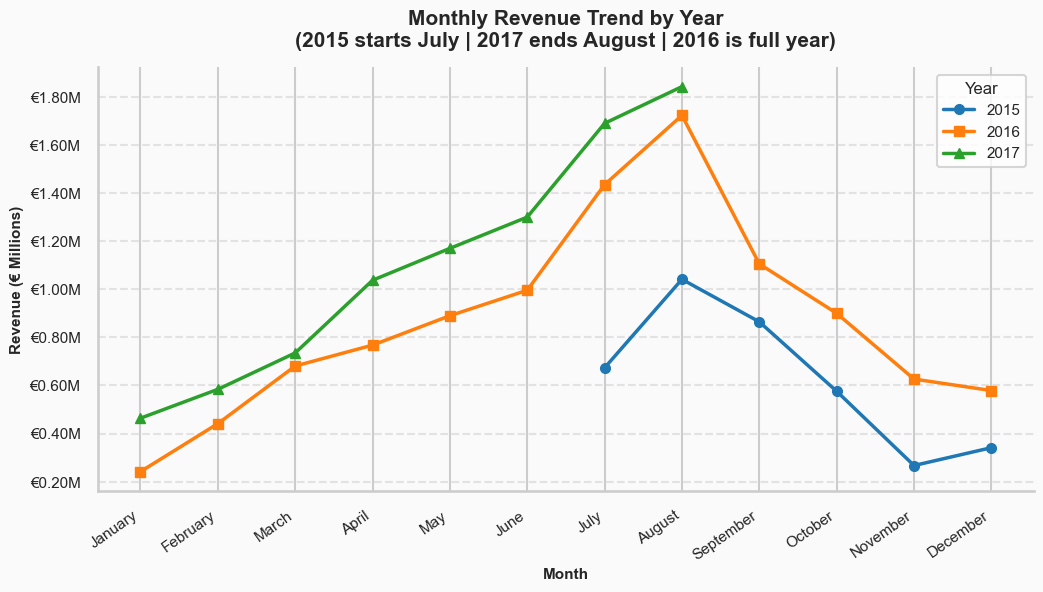

In [ ]:

# Chart 1: Monthly Revenue Trend by Year

# 1. Setup Month Order
MONTH_ORDER = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

# 2. Pivot the data to mimic your excel sheet exactly
# Added observed=False here to eliminate the FutureWarning
pivot_df = confirmed.pivot_table(
    index="arrival_date_month",
    columns="arrival_date_year",
    values="revenue",
    aggfunc="sum",
    observed=False,
)

# Force the strict calendar order
pivot_df = pivot_df.reindex(MONTH_ORDER)

# --- THE MAGIC FIX ---
# Replace any 0 values with NaN so matplotlib shows lines plotted where there is no data instead of breaking the line with a 0 value
pivot_df = pivot_df.replace(0, np.nan)
# ---------------------

# 3. Plotting Setup
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

year_colors = {2015: "#1f77b4", 2016: "#ff7f0e", 2017: "#2ca02c"}
year_markers = {2015: "o", 2016: "s", 2017: "^"}

# 4. Generate Lines
for year in pivot_df.columns:
    revenue_in_millions = pivot_df[year] / 1.0e6
    ax.plot(
        pivot_df.index,
        revenue_in_millions,
        marker=year_markers.get(year, "o"),
        markersize=7,
        linewidth=2.5,
        color=year_colors.get(year),
        label=str(int(year)),
    )

# 5. Clean Formatting
ax.set_title(
    'Monthly Revenue Trend by Year\n'
    '(2015 starts July | 2017 ends August | 2016 is full year)',
    fontsize=15, fontweight='bold', pad=15
)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Revenue (€ Millions)", fontsize=11)

plt.xticks(rotation=35, ha="right")

# Format Y-Axis ticks beautifully (€1.50M)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.2f}M"))

# Extra padding on the left side so '€0.00M' has plenty of room
fig.subplots_adjust(left=0.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Year")

plt.show()

## **Revenue Insights**

The monthly revenue trend highlights clear seasonality in hotel demand and revenue performance.

**Peak month:** August 2017 — €3,131,402.33  
**Lowest month:** January 2016 — €340,233.69  

### **Observations**

- August is the strongest revenue month across all available years, reflecting peak summer demand.
- 2016 is the only year with a full January-to-December record, so it provides the best basis for annual comparison.
- 2015 includes data only from July onward, while 2017 is available only up to August.
- August revenue increased consistently year over year:
  - 2015: €1,405,796.27
  - 2016: €2,703,454.39
  - 2017: €3,131,402.33
- November and December show comparatively lower revenue, suggesting a clear off-season effect.
***

C:\Users\Asus\AppData\Local\Temp\ipykernel_35512\433131262.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("market_segment")


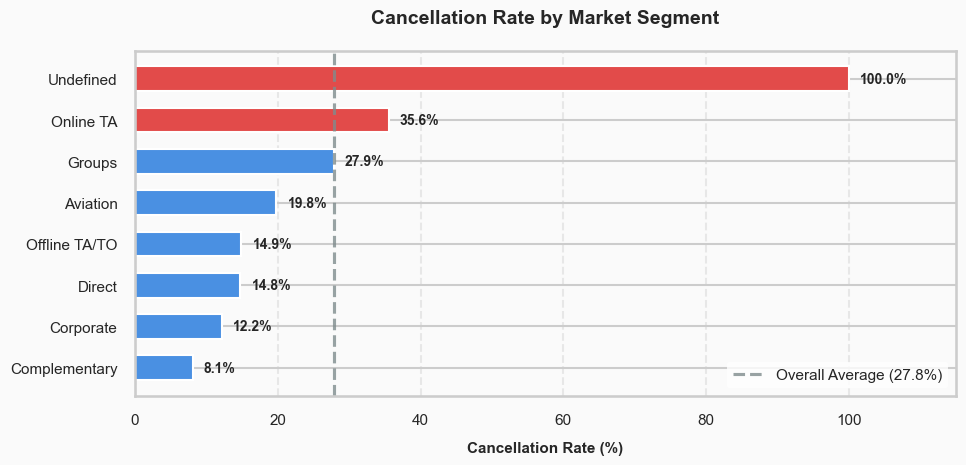

In [ ]:

# Chart 2: Cancellation Rate by Market Segment

# 1. Aggregate and calculate rates cleanly
seg = (
    df.groupby("market_segment")
    .agg(total=("is_canceled", "count"), canceled=("is_canceled", "sum"))
    .reset_index()
)

seg["rate"] = (seg["canceled"] / seg["total"]) * 100
seg = seg.sort_values("rate", ascending=True)

# 2. Setup the chart layout
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# Highlight segments with >30% cancellation rate in red, others in muted blue
colors = ["#E24B4A" if x > 30 else "#4A90E2" for x in seg["rate"]]
bars = ax.barh(seg["market_segment"], seg["rate"], color=colors, height=0.6)

# 3. Use Matplotlib's built-in container labels (No complex math loops needed!)
# This automatically handles the Y positioning and centers the text perfectly
ax.bar_label(bars, padding=8, fmt="%.1f%%", fontsize=10, fontweight="bold")

# 4. Reference lines and styling
overall_avg = df["is_canceled"].mean() * 100
ax.axvline(
    x=overall_avg,
    color="#7F8C8D",
    linestyle="--",
    alpha=0.8,
    label=f"Overall Average ({overall_avg:.1f}%)",
)

# 5. Clean, professional formatting
ax.set_title("Cancellation Rate by Market Segment", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Cancellation Rate (%)", fontsize=11, labelpad=10)
ax.set_xlim(0, max(seg["rate"]) * 1.15)  # Dynamic limit to give text breathing room

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.legend(loc="lower right", frameon=True, facecolor="#FFFFFF", edgecolor="none")

plt.tight_layout()
plt.show()

## **Cancellation Rate Insights (By Market Segment)**

- The **Undefined** segment is a complete loss, with a **100% cancellation rate**. This may indicate a small test category or a data issue, but every booking in this segment was canceled.
- **Online Travel Agents (Online TAs)** are the biggest operational risk, with a **35.6% cancellation rate**. Since they usually contribute high booking volume, they create major pressure on room planning and revenue forecasting.
- **Groups** sit almost exactly on the overall baseline, with a **27.9% cancellation rate** versus an overall average of **27.8%**. Even so, group cancellations can still cause sudden occupancy drops because multiple rooms are affected at once.
- **Direct** bookings (**14.8%**) and **Corporate** bookings (**12.2%**) are highly dependable, canceling at roughly half the company average. These segments represent stable revenue and stronger customer commitment.
- **Complementary** stays are the most secure segment, with only an **8.1% cancellation rate**, suggesting that free or promotional stays are rarely forfeited.
***

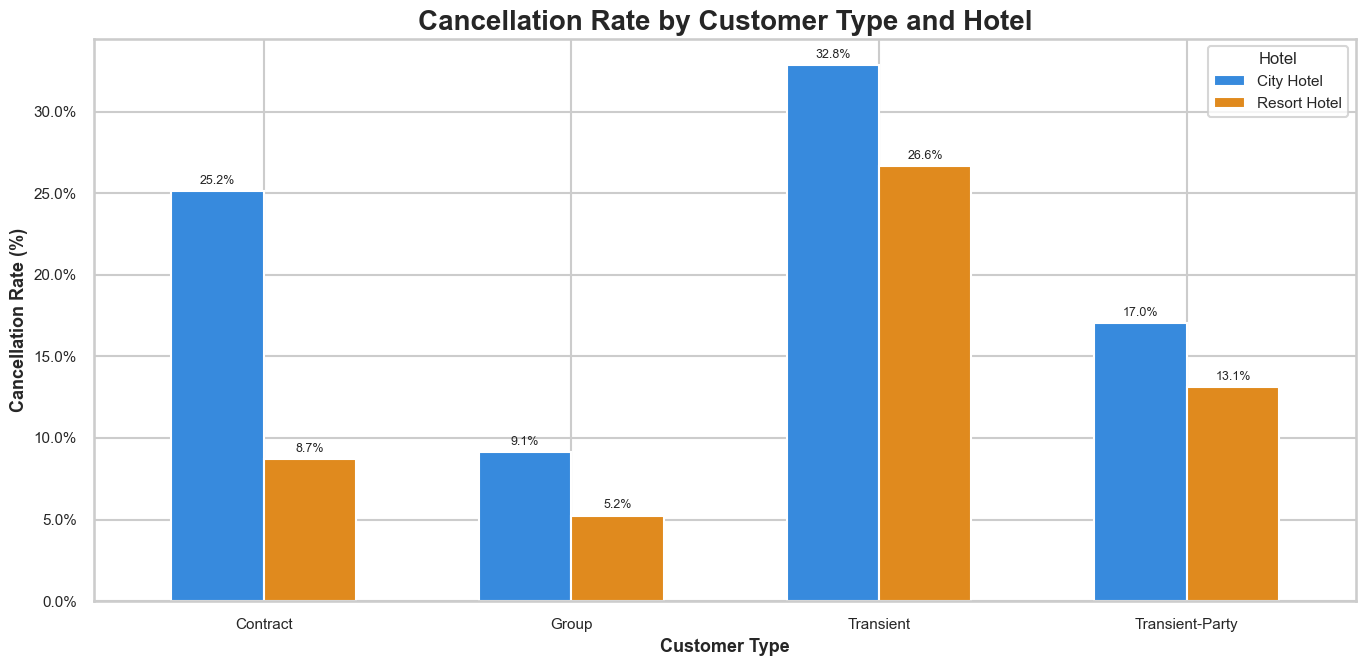

In [ ]:

# Chart 3: Cancellation Rate by Customer Type and Hotel

ct = df.groupby(['customer_type', 'hotel'], observed=False)['is_canceled'].mean().reset_index()
ct['rate'] = ct['is_canceled'] * 100

fig, ax = plt.subplots()
ct_pivot = ct.pivot(index='customer_type', columns='hotel', values='rate')
ct_pivot.plot(kind='bar', ax=ax, color=['#378ADD','#E08A1E'],
              edgecolor='white', width=0.6)

ax.set_title('Cancellation Rate by Customer Type and Hotel')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticklabels(ct_pivot.index, rotation=0)
ax.legend(title='Hotel')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## **Cancellation Rate Insights (By Customer Type & Hotel)**

- **Transient customers are the highest risk segment overall.** They show the strongest volatility, with a **32.8% cancellation rate** at City Hotels and **26.6%** at Resort Hotels.
- **City Hotels consistently suffer higher cancellation rates** across every customer category. This suggests city demand is more uncertain than resort demand.
- **Contract bookings show the largest gap between hotel types.** City Hotels record a high **25.2% cancellation rate**, while Resort Hotels are much more stable at **8.7%**.
- **Group bookings are the most reliable customer type.** They remain low-risk in both hotel types, with cancellations of just **9.1%** at City Hotels and **5.2%** at Resort Hotels.
- **Transient-Party bookings represent moderate risk.** Their cancellation rates sit in the middle at **17.0%** for City Hotels and **13.1%** for Resort Hotels.
***

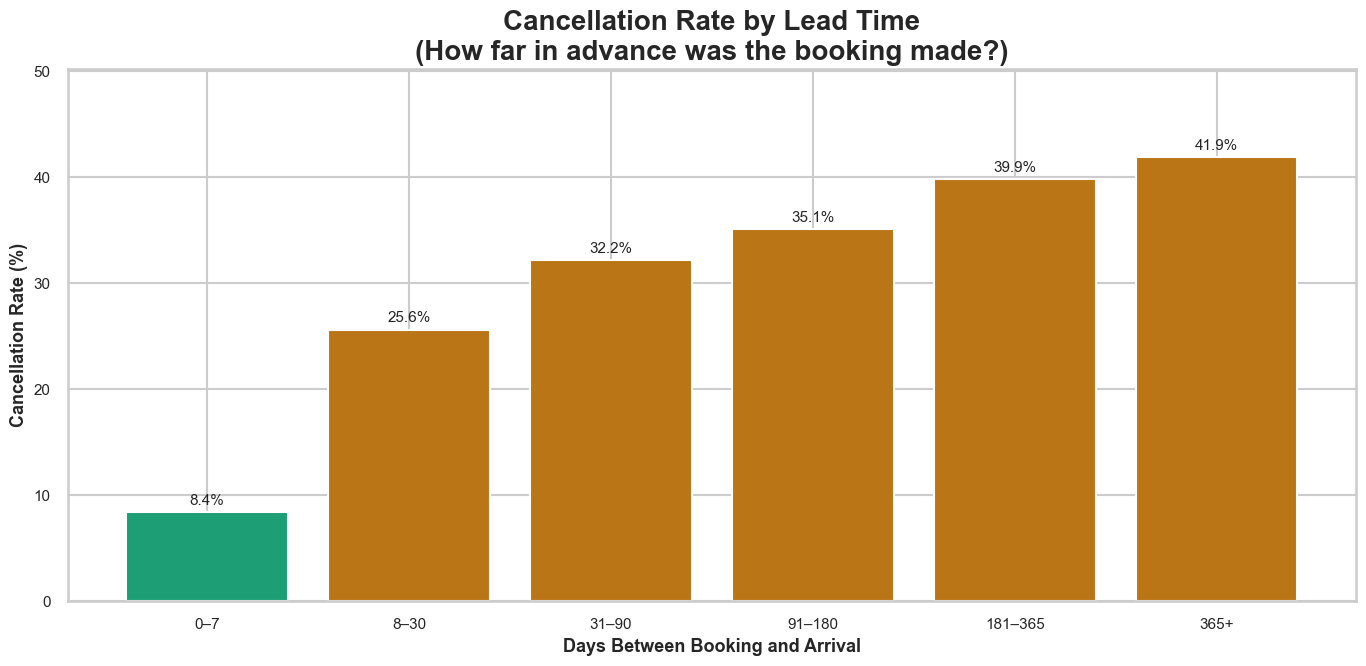

In [88]:

# Chart 4: Cancellation Rate by Lead Time Buckets

df['lead_bucket'] = pd.cut(
    df['lead_time'],
    bins=[0, 7, 30, 90, 180, 365, df['lead_time'].max()],
    labels=['0–7','8–30','31–90','91–180','181–365','365+'],
    include_lowest=True
)
lead = df.groupby('lead_bucket', observed=True)['is_canceled'].mean() * 100

fig, ax = plt.subplots()
colors = ['#1D9E75' if v < 25 else '#BA7517' if v < 45 else '#E24B4A'
          for v in lead.values]
bars = ax.bar(lead.index.astype(str), lead.values, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)

ax.set_title('Cancellation Rate by Lead Time\n(How far in advance was the booking made?)')
ax.set_xlabel('Days Between Booking and Arrival')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, max(lead.values) * 1.2)
plt.tight_layout()
plt.show()

## **Cancellation Rate by Lead Time - Key Insights**

* **Clear Trend — Further in Advance Means Higher Risk**
  There is a direct, step-by-step increase in cancellations the earlier a customer books. The further out a booking is made, the less likely the guest is to show up.
  
* **Last-Minute Bookings Are Incredibly Secure**
  Bookings made a week or less in advance (**0–7 days**) are the safest, with an incredibly low cancellation rate of just **8.4%**.

* **The 30-Day Mark Triggers a Warning Threshold**
  Once a booking passes 30 days of lead time, the cancellation rate jumps into the warning zone, climbing from **25.6%** (8–30 days) up to **32.2%** (31–90 days).

* **Long-Term Bookings Pose the Greatest Risk**
  Bookings made over half a year in advance are highly volatile. Cancellations reach **39.9%** for bookings made 181–365 days out, and peak at a staggering **41.9%** for bookings made more than a year (**365+ days**) in advance.



### **Strategic Recommendation**

> **Action Item:** To protect inventory and stabilize revenue, operations should implement stricter deposit requirements or offer targeted non-refundable discounts for any bookings made more than **30 to 90 days** out.

***

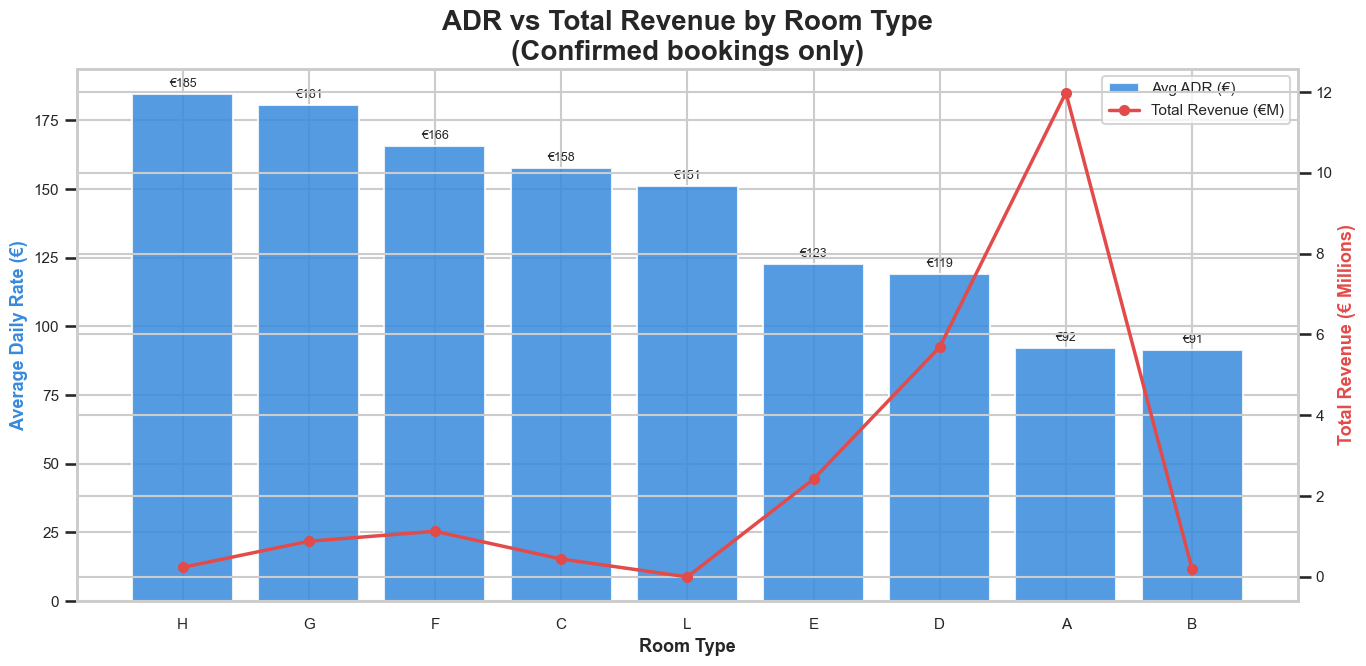

In [94]:

# Chart 5: ADR vs Total Revenue by Room Type (Confirmed bookings only)

room = confirmed.groupby('reserved_room_type').agg(
    avg_adr = ('adr', 'mean'),
    total_revenue = ('revenue', 'sum'),
    bookings = ('adr', 'count')
).reset_index().sort_values('avg_adr', ascending=False)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

bars = ax1.bar(room['reserved_room_type'], room['avg_adr'],
               color='#378ADD', alpha=0.85, label='Avg ADR (€)')
line = ax2.plot(room['reserved_room_type'], room['total_revenue'] / 1e6,
         color='#E24B4A', marker='o', linewidth=2.5,
         markersize=7, label='Total Revenue (€M)')

ax1.set_title('ADR vs Total Revenue by Room Type\n(Confirmed bookings only)')
ax1.set_xlabel('Room Type')
ax1.set_ylabel('Average Daily Rate (€)', color='#378ADD')
ax2.set_ylabel('Total Revenue (€ Millions)', color='#E24B4A')
ax1.bar_label(bars, fmt='€%.0f', padding=3, fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


## **ADR VS Total Room Revenue by Room Type Key Insights**

* **Room Type A is the Undisputed Financial Driver:** Despite sitting on the lower end of the pricing spectrum with an Average Daily Rate (ADR) of just €92, Room Type A generates your absolute highest revenue peak at a staggering €12 Million. The business relies heavily on the sheer volume of these bookings rather than premium pricing.

* **The Premium Room Paradox (High Price, No Revenue):** Room types H, G, F, C, and L successfully command your highest average rates, scaling from €151 up to €185. However, their corresponding total revenue is critically low—virtually scraping €0M to €1.5M along the red trend line. They are premium products that lack the booking volume to move the financial needle.

* **Room Type D is a Balanced Sweet Spot:** Room Type D represents a healthy middle ground. It commands a solid ADR of €119 while generating a strong secondary revenue peak of approximately €5.5 Million.

* **Room Type B is Low-Value and Low-Yield:** Room Type B has the lowest performance on the chart. It yields your lowest ADR at €91 and contributes almost nothing to total earnings, dropping back down near the €0M baseline.
***

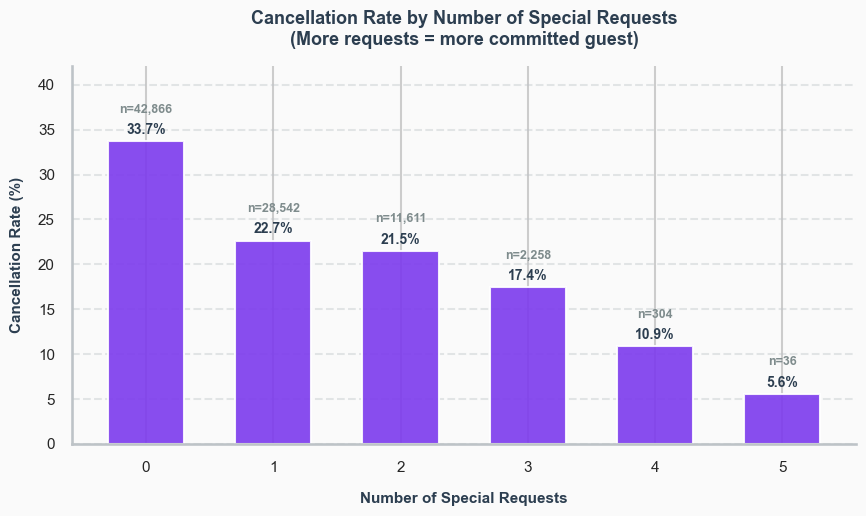

In [ ]:

# Chart 6: Cancellation Rate by Number of Special Requests

import matplotlib.pyplot as plt

# 1. Aggregate data using simple, clear variables
cancellation_rates = df.groupby("total_of_special_requests")["is_canceled"].mean() * 100
booking_counts = df.groupby("total_of_special_requests").size()

request_labels = cancellation_rates.index.astype(str)
rates_values = cancellation_rates.values

# 2. Create frame canvas size
plt.figure(figsize=(9, 5.5))

# 3. Use simple plt.bar
plt.bar(request_labels, rates_values, color="#7C3AED", width=0.6, alpha=0.9)

# 4. Add both text values stacked above the bars using a basic loop
for index in range(len(rates_values)):
    current_rate = rates_values[index]
    current_count = booking_counts.values[index]
    
    # Percentage label (e.g., 45.2%) placed right at the top edge of the bar
    plt.text(
        x=index,
        y=current_rate + 0.8,
        s=f"{current_rate:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#2C3E50"
    )
    
    # Sample size count label (e.g., n=70,000) stacked cleanly above the percentage
    plt.text(
        x=index,
        y=current_rate + 3.2,
        s=f"n={current_count:,}",
        ha="center",
        fontsize=9,
        color="#7F8C8D",
        fontweight="semibold"
    )

# 5. Final chart formatting details
plt.grid(axis="y", linestyle="--", alpha=0.4, color="#BDC3C7")

plt.title(
    "Cancellation Rate by Number of Special Requests\n(More requests = more committed guest)",
    fontsize=13,
    fontweight="bold",
    pad=15,
    color="#2C3E50"
)
plt.xlabel("Number of Special Requests", fontsize=11, fontweight="bold", labelpad=12, color="#2C3E50")
plt.ylabel("Cancellation Rate (%)", fontsize=11, fontweight="bold", labelpad=10, color="#2C3E50")

# Set the Y-axis boundary to start exactly at 0, leaving extra room at the top for labels
plt.ylim(0, max(rates_values) * 1.25)

plt.tight_layout()
plt.show()

## **Cancellation Rate by Numers of special Requests - Key Findings**

* **Special Requests Directly Linked to Commitment**
  There is a clear, step-down relationship between special requests and cancellations. Guests with **0 requests** cancel at a high rate of **33.7%**, while guests with **5 requests** drop drastically to a mere **5.6%** cancellation rate.

* **The "Emotional Investment" Shield**
  Making special requests (e.g., asking for a baby crib, high floor, or extra pillows) indicates a highly planned trip. These guests are emotionally and logistically invested, making them far less likely to abandon their booking.

* **Volume Lies at the Low End (The Sample Size Caveat)**
  While the low cancellation rates for 4 and 5 requests look highly favorable, the overwhelming majority of your data sits at 0 requests ($n=42,866$) and 1 request ($n=28,542$). Bookings with 5 requests ($n=36$) are incredibly rare anomalies.
***

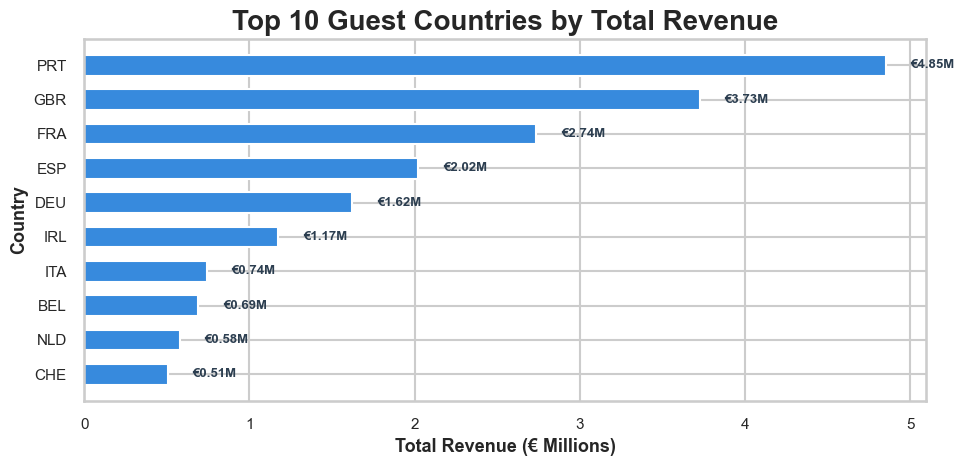

In [ ]:

# Chart 7: Top 10 Guest Countries by Total Revenue (Confirmed bookings only)

top10 = (
    confirmed.groupby("country", observed=False)["revenue"].sum().sort_values(ascending=False).head(10).reset_index()
)

top10_sorted = top10.iloc[::-1]

plt.figure(figsize=(10, 5))

plt.barh(
    top10_sorted["country"],
    top10_sorted["revenue"] / 1.0e6,
    color="#378ADD",
    height=0.6,
)

for i, v in enumerate(top10_sorted["revenue"] / 1.0e6):
    plt.text(
        v + 0.15,
        i,
        f"€{v:.2f}M",
        color="#2C3E50",
        va="center",
        fontsize=9.5,
        fontweight="bold",
)
    
plt.title("Top 10 Guest Countries by Total Revenue")
plt.xlabel("Total Revenue (€ Millions)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## **Top 10 Guest Countries by Total Revenue - Key Findings**

* **Portugal is the Primary Revenue Engine** **Portugal** (PRT) is your undisputed core market, driving a massive **€4.85 Million** in revenue. This indicates a dominant domestic or local-regional market share that serves as the baseline foundation for your business.

* **The Powerful Anglo-French Secondary Markets** **Great Britain** (GBR) at **€3.73 Million** and **France** (FRA) at **€2.74 Million** represent highly lucrative international pipelines. Together, these two neighboring countries pull in nearly €6.5 Million, making them the most vital targets for international premium marketing packages.

* **The Mid-Tier European Core** **Spain** (ESP) at **€2.02 Million** and **Germany** (DEU) at **€1.62 Million** showcase strong, reliable revenue generation. These established travel corridors represent steady, predictable business flows throughout standard seasonal booking cycles.

* **The Long-Tail Baseline** The remaining five countries—**Ireland** (IRL), **Italy** (ITA), **Belgium** (BEL), **Netherlands** (NLD), and **Switzerland** (CHE)—comprise your consistent long-tail international revenue base. While individual countries like Switzerland sit at a modest **€0.51 Million**, collectively this cluster contributes over **€3.6 Million** in high-value diversification.

### **Strategic Takeaway**

**Geographic Concentration Risk:** A significant portion of your top-tier market revenue relies heavily on a single country (Portugal). To optimize profitability and protect against sudden local economic variations, marketing budgets should look to actively scale customer acquisition campaigns in high-spending international zones like Great Britain and France, where international travelers often display higher average daily rates (ADR).
****

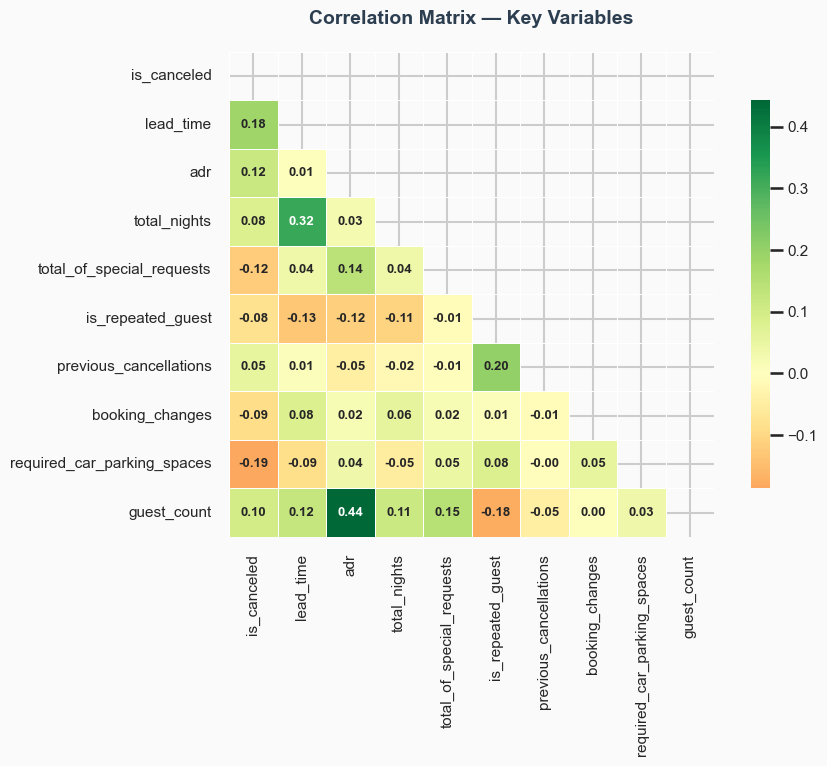

In [ ]:

# Chart 8: Correlation Matrix Heatmap (Key Variables)

key_variables = [
    "is_canceled",
    "lead_time",
    "adr",
    "total_nights",
    "total_of_special_requests",
    "is_repeated_guest",
    "previous_cancellations",
    "booking_changes",
    "required_car_parking_spaces",
    "guest_count",
]

# 2. Compute the correlation matrix table
correlation_matrix = df[key_variables].corr()

# 3. Create a triangle mask to block out the redundant top-right half of the grid
upper_triangle_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 4. Set global styles directly using simple plt.rcParams
plt.rcParams["figure.facecolor"] = "#FAFAFA"  # Outer window background
plt.rcParams["axes.facecolor"] = "#FAFAFA"    # Inner chart background
plt.rcParams["text.color"] = "#2C3E50"        # Labels and axis text color

# 5. Set the overall chart size frame
plt.figure(figsize=(10, 8))

# 6. Draw the heatmap using global configuration
sns.heatmap(
    correlation_matrix,
    mask=upper_triangle_mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9.5, "weight": "bold"},
)

# 7. Apply title directly using global plt
plt.title(
    "Correlation Matrix — Key Variables", fontsize=14, fontweight="bold", pad=20
)

plt.tight_layout()
plt.show()

## **Coorelation Matrix - Key Insights**

### 1. **Revenue Drivers & Room Strategy (Room Type Chart)**

* **The High-Volume Engine (Room Type A)**
  Room Type A is the undisputed backbone of your revenue, generating a massive peak of **€12 Million**. What makes this fascinating is that it has a relatively low Average Daily Rate (ADR) of just **€92**. Your business relies heavily on high-volume booking velocity rather than luxury price margins.

* **The "Premium Room" Vacancy Paradox**
  Your highest-tier rooms—**H, G, F, C, and L**—successfully command premium price points ranging from **€151 to €185**. However, their collective revenue contributions are critically low, virtually scraping the bottom of the trend line. This indicates these rooms are sitting empty most of the time or suffer from severe under-booking.

* **The Sweet Spot (Room Type D)**
  Room Type D strikes an excellent operational balance, commanding a healthy ADR of **€119** while generating a strong secondary revenue stream of roughly **€5.5 Million**.



### 2. **Key Cancellation & Behavior Drivers (Correlation Matrix)**

* **Lead Time is the Main Predictor of Cancellations**
  There is a positive correlation of **0.18** between `lead_time` and `is_canceled`. This is the strongest positive link to cancellations on the board, proving that the further in advance a guest books, the more likely they are to eventually cancel their stay.

* **Special Requests Shield Cancellations**
  A negative correlation of **-0.12** exists between `total_of_special_requests` and `is_canceled`. When guests take the time to ask for specific amenities (e.g., twin beds, high floors), they become emotionally invested in their trip and are significantly less likely to back out.

* **Parking Spaces Equal Guaranteed Check-ins**
  The strongest negative correlation to cancellations is `required_car_parking_spaces` at **-0.19**. Guests who explicitly request parking spaces almost never cancel, likely because a car trip implies definitive, locked-in travel plans.

* **The "Bigger Group, Higher Price" Dynamic**
  The matrix highlights a strong **0.44** correlation between `guest_count` and `adr`. As more people travel together in a single booking, they naturally opt for larger spaces or family suites, driving up the daily price yield significantly.
***

# **Export for SQL and Power BI**

In [118]:
pip install mysql-connector-python SQLAlchemy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
    --------------------------------------- 0.3/18.2 MB ? eta -:--:--
    --------------------------------------- 0.3/18.2 MB ? eta -:--:--
    --------------------------------------- 0.3/18.2 MB ? eta -:--:--
    --------------------------------------- 0.3/18.2 MB ? eta -:--:--
    --------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 283.0 kB/s eta 0:00:05
   ----------- ---------------------------- 0.5/1.8 MB 283.0 kB/s eta 0:00:05
   ----------- ---------------------------- 0.5/1.8 MB 283.0 kB/s eta 0:00:05
   ----------- ---------------------------- 0.5/1.8 MB 283.0 kB/s eta 0:00:05
   ----------- ---------------------------- 0.5/1.8 MB 283

In [122]:
import os
import pandas as pd
from sqlalchemy import create_engine

# 1. Load the clean tab explicitly from your Excel workbook
excel_file = "hotel_bookings.xlsx"
sheet_tab = "CLEAN"

print(f"Reading data from file '{excel_file}', tab '{sheet_tab}'...")
df = pd.read_excel(excel_file, sheet_name=sheet_tab)
print(f"✓ Loaded {len(df):,} rows from Excel.")

# 2. Re-format date columns cleanly to prevent MySQL syntax rejections
date_cols = [col for col in df.columns if "date" in col.lower()]
for col in date_cols:
    try:
        df[col] = pd.to_datetime(df[col]).dt.strftime("%Y-%m-%d")
    except Exception:
        pass

# 3. Clean column names (MySQL strictly forbids spaces or special characters)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# 4. Save a backup CSV copy in case you want to use it for Power BI directly later
os.makedirs("data/clean", exist_ok=True)
csv_path = "data/clean/hotel_bookings_clean.csv"
df.to_csv(csv_path, index=False)
print(f"✓ Backup CSV saved for Power BI: {csv_path}")


# 5. MYSQL WORKBENCH CONNECTION SETUP

USER = "root"
PASSWORD = "3463"  # Type your MySQL root password here
HOST = "localhost"
PORT = "3306"                    # Default MySQL port
DATABASE = "hotel_bookings"    # Make sure you run 'CREATE DATABASE hotel_analytics;' in Workbench first!

# Create a secure SQLAlchemy engine connection link
connection_string = f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_string)

print(f"\nConnecting to MySQL Server and uploading to database '{DATABASE}'...")

# Push data to MySQL table named 'bookings'
df.to_sql(
    name="bookings",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=2000  # Smaller batch sizes prevent MySQL packets from timing out
)

print(f"✓ Success! Table 'bookings' is now fully populated in MySQL Workbench.")
print(f"Final verified data shape sent to SQL: {df.shape}")

Reading data from file 'hotel_bookings.xlsx', tab 'CLEAN'...
✓ Loaded 85,617 rows from Excel.


C:\Users\Asus\AppData\Local\Temp\ipykernel_35512\2808226454.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col]).dt.strftime("%Y-%m-%d")


✓ Backup CSV saved for Power BI: data/clean/hotel_bookings_clean.csv

Connecting to MySQL Server and uploading to database 'hotel_bookings'...
✓ Success! Table 'bookings' is now fully populated in MySQL Workbench.
Final verified data shape sent to SQL: (85617, 39)


***Having proble with arrival_date_year, "arrival_date_month", 
    "arrival_date_day_of_month", 
    "arrival_date_week_number" columns. Droping whole table and pushing it again***

In [124]:
import os
import pandas as pd
from sqlalchemy import create_engine

# 1. Load data fresh from Excel
df = pd.read_excel("hotel_bookings.xlsx", sheet_name="CLEAN")
print(f"✓ Successfully loaded {len(df):,} rows from Excel.")

# 2. KEEP ALL COLUMNS & FIX NUMERIC FORMATTING
# Convert year, day, and week to clean integers to remove any hidden floating decimals (like 2015.0)
df["arrival_date_year"] = df["arrival_date_year"].fillna(0).astype(int)
df["arrival_date_day_of_month"] = df["arrival_date_day_of_month"].fillna(0).astype(int)
df["arrival_date_week_number"] = df["arrival_date_week_number"].fillna(0).astype(int)

# Keep the month column as a clean string/text category
df["arrival_date_month"] = df["arrival_date_month"].astype(str).str.strip()
print("✓ Formatted all split date columns safely (Integers and Text strings preserved).")

# 3. Clean up the combined master date and status date columns for MySQL compliance
date_columns = ["arrival_date", "reservation_status_date"]
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.strftime("%Y-%m-%d")

# 4. Standardize all column names to lowercase snake_case (MySQL naming standard)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# 5. Push the completely intact dataset directly to MySQL Workbench
USER = "root"
PASSWORD = "3463"  # Your MySQL password
HOST = "localhost"
PORT = "3306"
DATABASE = "hotel_bookings"

connection_string = f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_string)

print(f"\nRewriting entire database table with all columns intact to schema '{DATABASE}'...")
df.to_sql(
    name="bookings",
    con=engine,
    if_exists="replace",  # Safely drops the broken structure and replaces it with this perfect copy
    index=False,
    chunksize=2000
)

print("\n🎯 Success! Every single column has been transferred exactly as it is in your Excel file.")

✓ Successfully loaded 85,617 rows from Excel.
✓ Formatted all split date columns safely (Integers and Text strings preserved).

Rewriting entire database table with all columns intact to schema 'hotel_bookings'...

🎯 Success! Every single column has been transferred exactly as it is in your Excel file.
